In [7]:

import os
import csv
import numpy as np
import librosa
import librosa.display
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [8]:
# --- CONFIGURA AQUÍ TU AUDIO ---
AUDIO_PATH = r"C:\Users\Brenda\Desktop\ORENETES\janebeta7-repo-main\Processing_sculpture\audios ocells\audio_oronetes_tivissa\260704_0243.63.wav"      # Cambia esto por el nombre de tu archivo de audio
OUT_CSV = "pca_points_oreneta.csv"
N_MFCC = 13
N_MELS = 64
N_FFT = 2048
HOP_LENGTH = 256
# -------------------------------

In [9]:
if not os.path.isfile(AUDIO_PATH):
    raise FileNotFoundError(f"No se encuentra el audio: {AUDIO_PATH}")

# 1. Carga el audio (y = datos de audio, sr = frecuencia de muestreo)
print("Cargando audio:", AUDIO_PATH)
y, sr = librosa.load(AUDIO_PATH, sr=None)
duracion = len(y) / sr
print(f"SR={sr}, duración={duracion:.2f}s")

Cargando audio: C:\Users\Brenda\Desktop\ORENETES\janebeta7-repo-main\Processing_sculpture\audios ocells\audio_oronetes_tivissa\260704_0243.63.wav
SR=48000, duración=1.35s


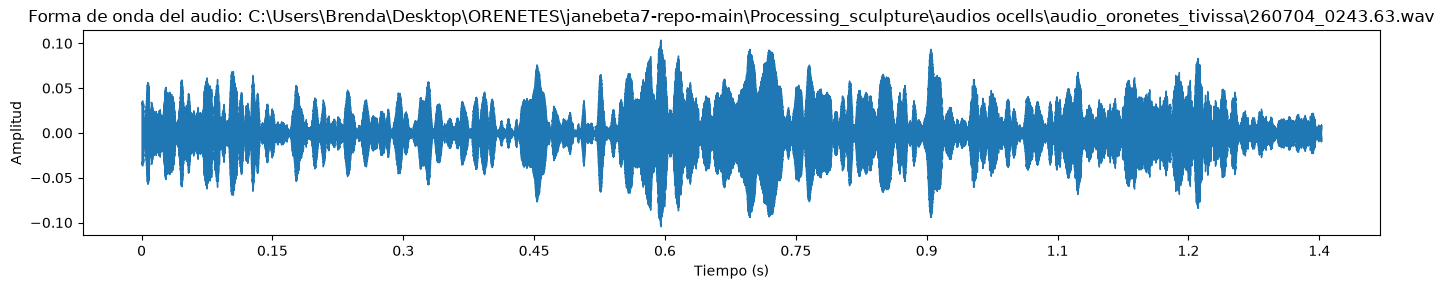

In [10]:
# 2. Visualiza la forma de onda
plt.figure(figsize=(14, 3))
librosa.display.waveshow(y, sr=sr)
plt.title(f'Forma de onda del audio: {AUDIO_PATH}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.tight_layout()
plt.show()

Calculando espectrograma Mel...


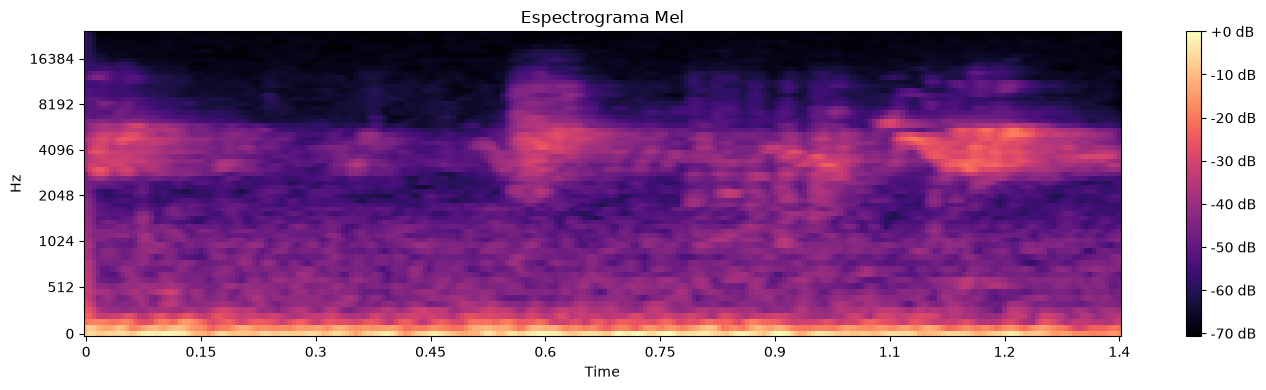

In [11]:
# 3. Calcula y grafica el espectrograma Mel
print("Calculando espectrograma Mel...")
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(14, 4))
librosa.display.specshow(mel_spec_db, y_axis='mel', x_axis='time', sr=sr, hop_length=HOP_LENGTH)
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma Mel')
plt.tight_layout()
plt.show()

In [12]:
# 4. Calcula y grafica los MFCC
print("Calculando MFCC...")
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)


Calculando MFCC...


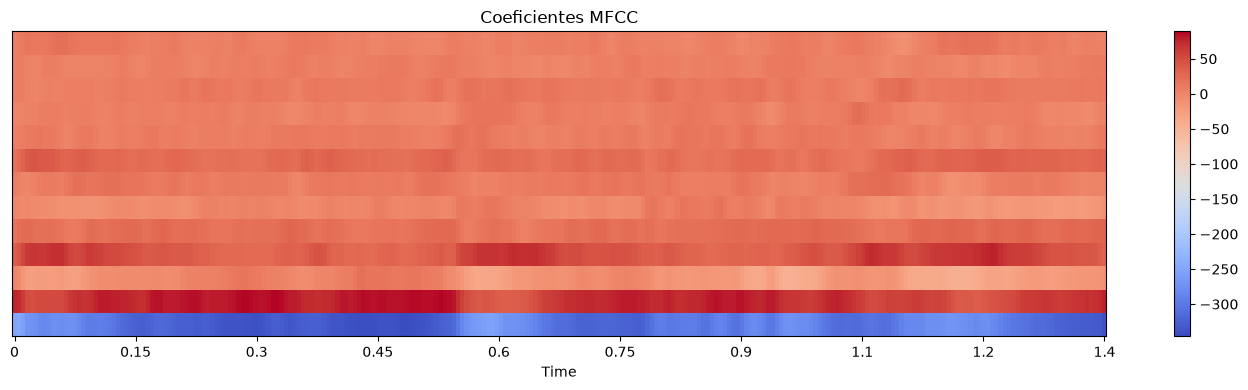

In [13]:
plt.figure(figsize=(14, 4))
librosa.display.specshow(mfcc, x_axis='time', sr=sr, hop_length=HOP_LENGTH)
plt.colorbar()
plt.title('Coeficientes MFCC')
plt.tight_layout()
plt.show()

In [14]:
# 5. Calcula energía (RMS)
print("Calculando energía por frame (RMS)...")
rms = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)[0]

Calculando energía por frame (RMS)...


In [15]:
# 6. Reduce MFCCs a 3D con PCA
print("Aplicando PCA 3D a los MFCC...")
X = mfcc.T  # (n_frames, n_mfcc)
pca = PCA(n_components=3)
Xp = pca.fit_transform(X)
print("Varianza explicada PC1-PC3:", pca.explained_variance_ratio_)

Aplicando PCA 3D a los MFCC...
Varianza explicada PC1-PC3: [0.67647445 0.1341797  0.07274902]


In [16]:
# 7. Normalización y preparación de datos para exportar

# El tiempo en segundos de cada frame nos permite saber a qué instante corresponde cada fila del CSV.
# Así, podemos sincronizar los datos con el audio original o hacer análisis temporal fácilmente.
n_frames = Xp.shape[0]
times = librosa.frames_to_time(np.arange(n_frames), sr=sr, hop_length=HOP_LENGTH)

In [17]:
# Normalizamos el tiempo a valores entre 0 y 1.
# Esto es útil si queremos comparar audios de distinta duración o usar los datos en modelos que requieran este rango.
t_norm = (times - times.min()) / (times.max() - times.min() + 1e-12)

In [18]:
# Normalizamos la energía (rms) para que sus valores estén entre 0 y 1.
# Así, independientemente del volumen absoluto del audio, podemos comparar la energía relativa de cada frame.
rms = rms[:n_frames]
energy_norm = (rms - rms.min()) / (rms.max() - rms.min() + 1e-12)

In [19]:
# 8. Exporta a CSV
print("Guardando datos en el CSV:", OUT_CSV)
with open(OUT_CSV, "w", newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["x", "y", "z", "time_norm", "energy_norm", "frame_index", "time_s"])
    for i in range(n_frames):
        x, y_, z = map(float, Xp[i])
        # En cada fila ponemos: las 3 dimensiones PCA, tiempo normalizado, energía normalizada,
        # índice de frame y tiempo real en segundos.
        writer.writerow([x, y_, z, float(t_norm[i]), float(energy_norm[i]), int(i), float(times[i])])

print("¡Hecho! CSV creado en:", os.path.abspath(OUT_CSV))

Guardando datos en el CSV: pca_points_oreneta.csv
¡Hecho! CSV creado en: C:\Users\Brenda\pca_points_oreneta.csv
